### Building a Chatbot with Langgraph using GraphAPI


In [15]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [16]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends message to  list, rather than overwriting them)

    messages: Annotated[list, add_messages]
graph_buidler = StateGraph(State)

In [17]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [18]:
from langchain_mistralai import ChatMistralAI

llm = ChatMistralAI(
    model_name="mistral-medium-3-5"
)

In [19]:
# Node functionality
def chatbot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}

In [20]:
graph_buidler = StateGraph(State)
graph_buidler.add_node("llmChatbot", chatbot)

graph_buidler.add_edge(START, "llmChatbot")
graph_buidler.add_edge("llmChatbot", END)

## Compile the graph

graph = graph_buidler.compile()

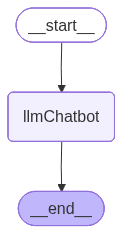

In [21]:
# Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [24]:
response =graph.invoke({"messages":"Hello"})

In [26]:
response["messages"][-1].content

'Hello! How can I assist you today?'

In [27]:
for event in graph.stream({"messages":"Hello, how are you?"}):
    print(event)

{'llmChatbot': {'messages': [AIMessage(content="Hello! 😊 I'm just a bunch of code, so I don't have feelings, but I'm here and ready to help you with anything you need! How about you—how are *you* doing today? Anything on your mind or something I can assist with?", additional_kwargs={}, response_metadata={'token_usage': {'prompt_tokens': 21, 'total_tokens': 79, 'completion_tokens': 58, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'mistral-medium-3-5', 'model': 'mistral-medium-3-5', 'finish_reason': 'stop', 'model_provider': 'mistralai'}, id='lc_run--019f0e6f-82b6-7740-9f38-239a01e16ac4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 21, 'output_tokens': 58, 'total_tokens': 79})]}}
